# Preprocessing Text  
Terdapat 7 tahapan dalam preprocessing text yakni:  
1. Case Folding  
2. Remove Special Characters
3. Menghapus Angka
4. Menghapus Tanda Baca
5. Typo Correction
6. Tokenizing 
7. Stopword
8. Stemming  

Setelah itu dilakukan labeling data dengan 3 kelas yaitu positive, netral, dan negative berdasarkan lexicon (score polarity)

## Import Library

In [1]:
import re
import string
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import emoji
from tqdm import tqdm
from wordcloud import WordCloud
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
from spellchecker import SpellChecker

# Download NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ANDIK\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ANDIK\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ANDIK\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ANDIK\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ANDIK\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [2]:
data = pd.read_csv('../data/ulasan_mobile_legends_70k.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              70000 non-null  object
 1   userName              70000 non-null  object
 2   userImage             70000 non-null  object
 3   content               70000 non-null  object
 4   score                 70000 non-null  int64 
 5   thumbsUpCount         70000 non-null  int64 
 6   reviewCreatedVersion  56638 non-null  object
 7   at                    70000 non-null  object
 8   replyContent          1749 non-null   object
 9   repliedAt             1749 non-null   object
 10  appVersion            56638 non-null  object
dtypes: int64(2), object(9)
memory usage: 5.9+ MB


In [3]:
# Drop kolom yang tidak diperlukan
data = data.drop(columns=['reviewId', 'userName', 'userImage', 'replyContent', 'repliedAt', 'reviewCreatedVersion', 'appVersion', 'thumbsUpCount', 'at', 'score'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  70000 non-null  object
dtypes: object(1)
memory usage: 547.0+ KB


In [4]:
# Fungsi untuk normalisasi menggunakan kamus custom
def normalize_custom_kamus(text, kamus_dict):
    return ' '.join([kamus_dict.get(word, word) for word in text.split()])

# Fungsi untuk menghapus emoji
def remove_emoji(text):
    return emoji.replace_emoji(text, replace='')


# --- Fungsi Preprocessing Lengkap ---
def preprocess(text, kamus_custom):
    # 1. Case Folding
    text = text.lower()
    
    # 2. Remove Emoji
    text = remove_emoji(text)

    # 3. Remove Special Characters
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # 4. Menghapus Angka
    text = re.sub(r'\d+', '', text)
    
    # 5. Menghapus Tanda Baca
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 6. Normalisasi Kata (Menggunakan Kamus Custom)
    text = normalize_custom_kamus(text, kamus_custom)
    
    # 7. Tokenizing
    tokens = word_tokenize(text)
    
    # 8. Stopword Removal
    stopword_list = stopwords.words('english')
    tokens = [word for word in tokens if word not in stopword_list]
    
    # 9. Lemmatization 
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    return ' '.join(tokens)

# Fungsi untuk memuat kamus custom dari file
def load_custom_dictionary(filepath):
    custom_dict = {}
    with open(filepath, encoding='utf-8') as file:
        for line in file:
            if '=' in line:
                key, value = line.strip().split('=', 1)
                custom_dict[key.strip()] = value.strip()
    return custom_dict

# Load kamus custom
kamus_custom = load_custom_dictionary('../kamus_custom_en.txt')

In [5]:
# Contoh penggunaan fungsi preprocess
ulasan = "this game is amazing pls fix the bugs and add more features, thx :) 🤩"
processed_text = preprocess(ulasan, kamus_custom)
print(processed_text)

game amazing please fix bug add feature thanks


In [6]:
tqdm.pandas() # untuk progress bar
# Terapkan fungsi preprocess ke seluruh data
data['clean_review'] = data['content'].astype(str).progress_apply(lambda x: preprocess(x, kamus_custom))

100%|██████████| 70000/70000 [01:06<00:00, 1059.87it/s]


In [7]:
# Cek hasilnya
print(data[['content', 'clean_review']].head())

                                             content  \
0  Basically a better and more intuitive version ...   
1  I like the game. It's programmed well and bugs...   
2  It was good at first, but each time the app up...   
3  FIX MATCHMAKING. I cannot stand the one-sided ...   
4  The old Legend skins are completely outdated a...   

                                        clean_review  
0  basically better intuitive version lol mention...  
1  like game programmed well bug quite rare like ...  
2  good first time application updated becomes bu...  
3  fix matchmaking stand one sided skill matchmak...  
4  old legend skin completely outdated new epic s...  


## Labeling Data

In [8]:
sia = SentimentIntensityAnalyzer()

def label_from_lexicon(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.3:
        return 'positive'
    elif score <= -0.3:
        return 'negative'
    else:
        return 'neutral'

# Terapkan ke kolom clean_review
data['label_lexicon'] = data['clean_review'].progress_apply(lambda x: label_from_lexicon(x))

100%|██████████| 70000/70000 [00:19<00:00, 3636.04it/s]


In [9]:
data.head()

,content,clean_review,label_lexicon
0,Basically a better and more intuitive version ...,basically better intuitive version lol mention...,positive
1,I like the game. It's programmed well and bugs...,like game programmed well bug quite rare like ...,positive
2,"It was good at first, but each time the app up...",good first time application updated becomes bu...,positive
3,FIX MATCHMAKING. I cannot stand the one-sided ...,fix matchmaking stand one sided skill matchmak...,neutral
4,The old Legend skins are completely outdated a...,old legend skin completely outdated new epic s...,positive


## EDA

In [10]:
# Distribusi label berdasarkan lexicon
print("\nDistribusi Label dari Lexicon:")
print(data['label_lexicon'].value_counts())


Distribusi Label dari Lexicon:
label_lexicon
positive    38512
negative    19447
neutral     12041
Name: count, dtype: int64


C:\Users\ANDIK\AppData\Local\Temp\ipykernel_21696\513968304.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='label_lexicon', palette='coolwarm')


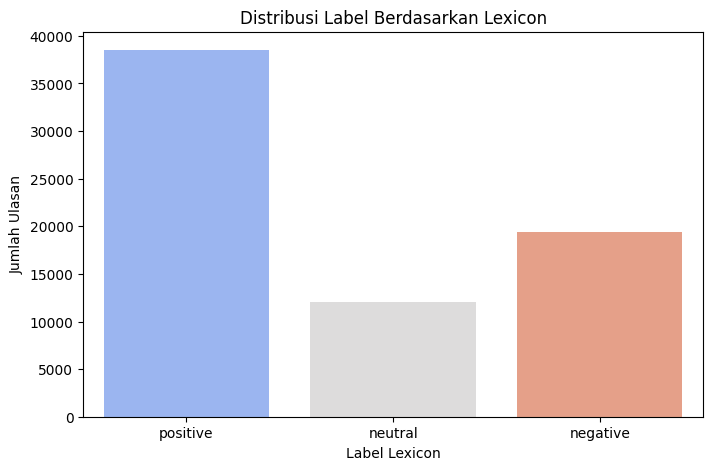

In [11]:
# Barplot untuk label_lexicon
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='label_lexicon', palette='coolwarm')
plt.title('Distribusi Label Berdasarkan Lexicon')
plt.xlabel('Label Lexicon')
plt.ylabel('Jumlah Ulasan')
plt.show()

In [12]:
def show_wordcloud(data, title=None):
    """
    Menampilkan WordCloud berdasarkan teks yang diberikan.

    Parameter:
    ----------
    data : list atau pandas.Series
        Data berupa kumpulan teks (list atau Series) yang akan digunakan untuk membuat WordCloud.
    title : str, opsional
        Judul yang akan ditampilkan di atas WordCloud. Default adalah None.

    Fungsi ini akan:
    - Menggabungkan semua teks dalam `data` menjadi satu string.
    - Membuat WordCloud menggunakan library WordCloud.
    - Menampilkan WordCloud menggunakan matplotlib.

    Contoh Penggunaan:
    ------------------
    show_wordcloud(data['clean_review'], title='WordCloud untuk Ulasan Bersih')
    """
    text = ' '.join(data)
    wordcloud = WordCloud(width=800, height=400, background_color='white',
                          max_words=200, collocations=False).generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    if title:
        plt.title(title, fontsize=16)
    plt.show()

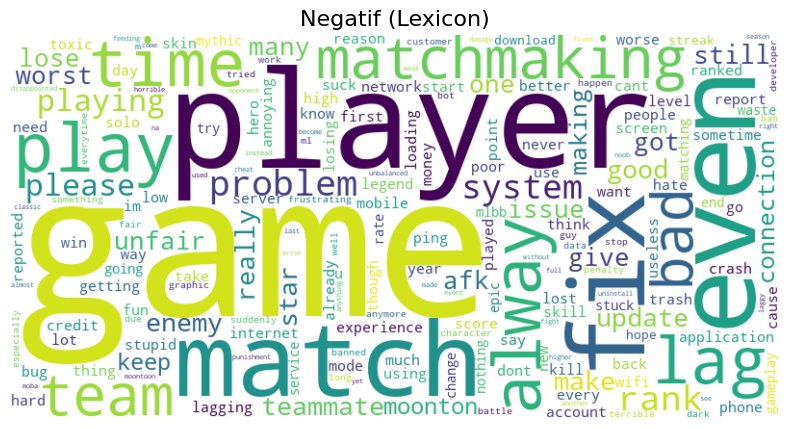

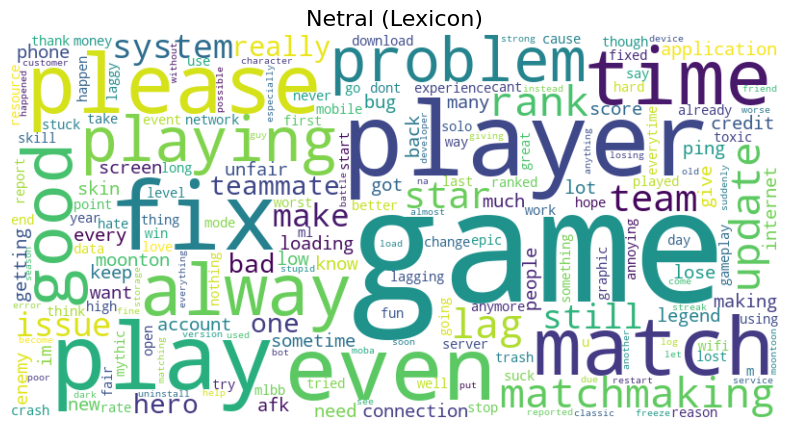

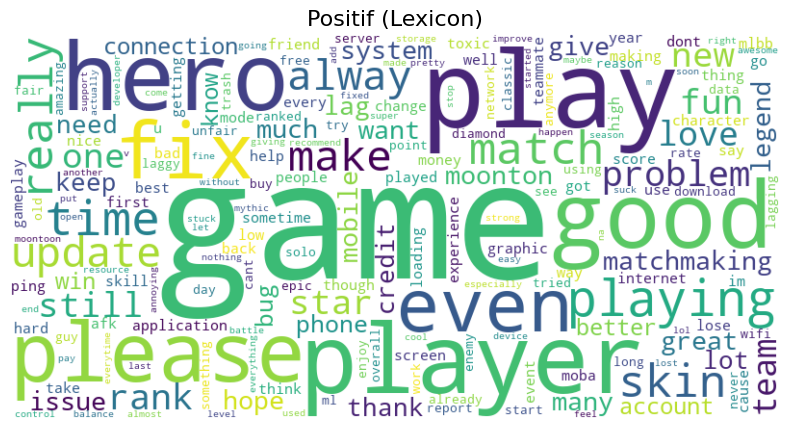

In [13]:
# Wordcloud untuk masing-masing label
show_wordcloud(data[data['label_lexicon'] == 'negative']['clean_review'], title='Negatif (Lexicon)')
show_wordcloud(data[data['label_lexicon'] == 'neutral']['clean_review'], title='Netral (Lexicon)')
show_wordcloud(data[data['label_lexicon'] == 'positive']['clean_review'], title='Positif (Lexicon)')

## Imbalanced Data

In [14]:
# Tentukan target undersampling
target = 12000

# Ambil sampel dari masing-masing kelas
positive_sample = data[data['label_lexicon'] == 'positive'].sample(n=target, random_state=42)
negative_sample = data[data['label_lexicon'] == 'negative'].sample(n=target, random_state=42)
neutral_sample = data[data['label_lexicon'] == 'neutral'].sample(n=target, random_state=42)

# Gabungkan ketiga kelas
undersampled_data = pd.concat([positive_sample, negative_sample, neutral_sample])

# Shuffle data biar random
undersampled_data = undersampled_data.sample(frac=1, random_state=42).reset_index(drop=True)

# Cek distribusi hasil
print("\nDistribusi setelah undersampling:")
print(undersampled_data['label_lexicon'].value_counts())
print(f"\nUndersampling selesai! Total data: {len(undersampled_data)}")


Distribusi setelah undersampling:
label_lexicon
negative    12000
neutral     12000
positive    12000
Name: count, dtype: int64

Undersampling selesai! Total data: 36000


In [15]:
undersampled_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36000 entries, 0 to 35999
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   content        36000 non-null  object
 1   clean_review   36000 non-null  object
 2   label_lexicon  36000 non-null  object
dtypes: object(3)
memory usage: 843.9+ KB


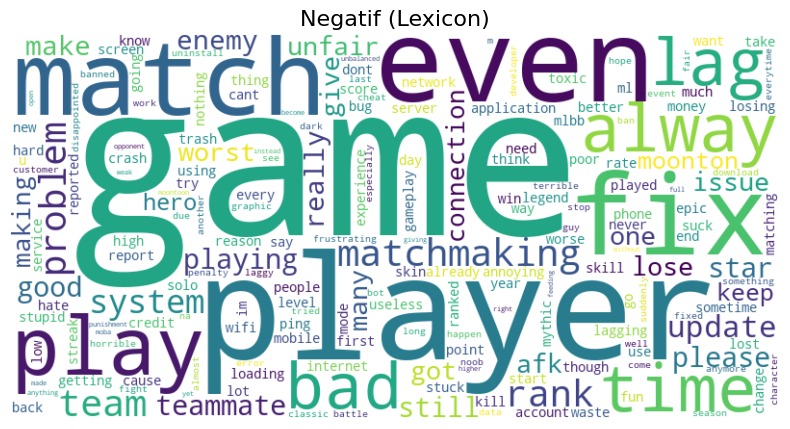

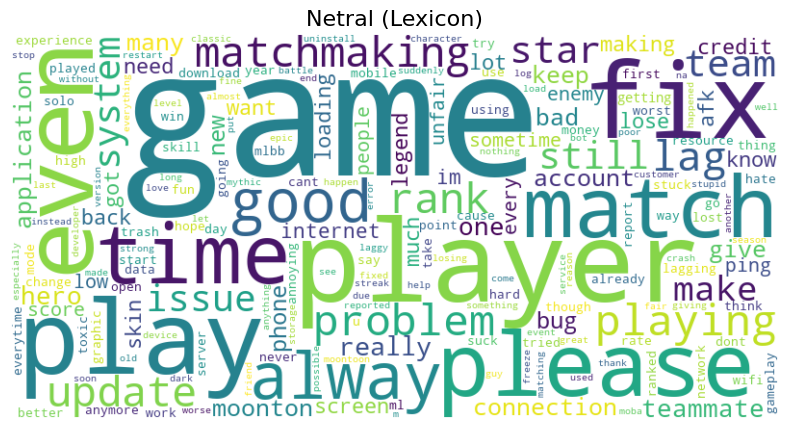

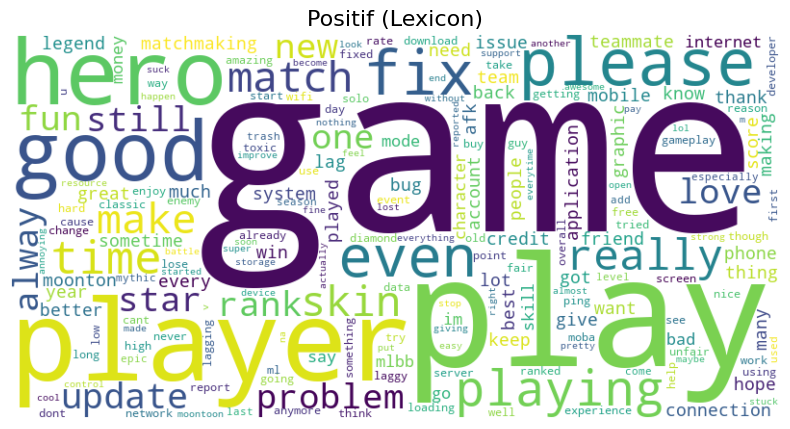

In [16]:
# Wordcloud untuk masing-masing label
show_wordcloud(undersampled_data[undersampled_data['label_lexicon'] == 'negative']['clean_review'], title='Negatif (Lexicon)')
show_wordcloud(undersampled_data[undersampled_data['label_lexicon'] == 'neutral']['clean_review'], title='Netral (Lexicon)')
show_wordcloud(undersampled_data[undersampled_data['label_lexicon'] == 'positive']['clean_review'], title='Positif (Lexicon)')

In [17]:
# Simpan data hasil preprocessing ke file baru (opsional)
undersampled_data.to_csv('../data/data_cleaned.csv', index=False)

count    36000.000000
mean        28.868667
std         12.372544
min          2.000000
25%         20.000000
50%         28.000000
75%         38.000000
max        196.000000
Name: text_length, dtype: float64


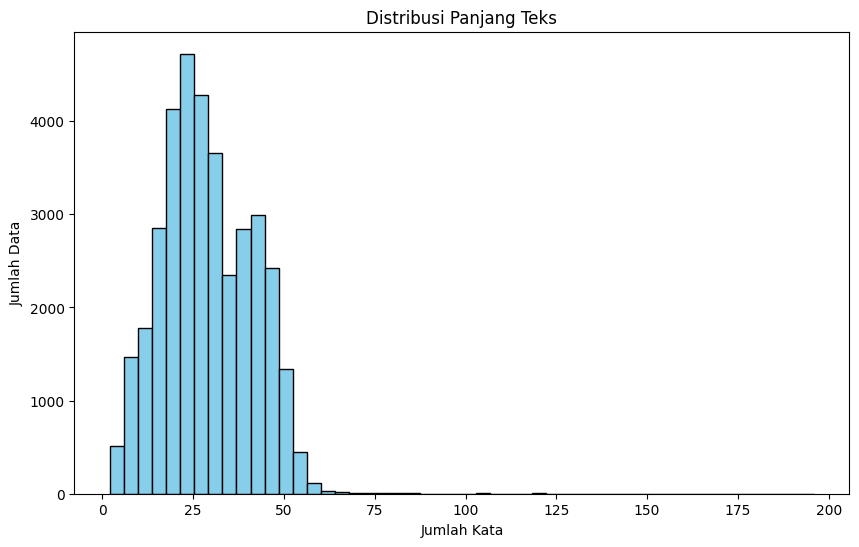

In [18]:
# Hitung panjang masing-masing teks
undersampled_data['text_length'] = undersampled_data['clean_review'].apply(lambda x: len(str(x).split()))

# Cek statistik umum
print(undersampled_data['text_length'].describe())

# Plot distribusi panjang teks
plt.figure(figsize=(10,6))
plt.hist(undersampled_data['text_length'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribusi Panjang Teks')
plt.xlabel('Jumlah Kata')
plt.ylabel('Jumlah Data')
plt.show()

In [19]:
undersampled_data.head()

,content,clean_review,label_lexicon,text_length
0,Played a game as atlas just now my S2 bugged o...,played game atlas bugged bad tp mid move durat...,negative,41
1,Back to greatness! In the past I would usually...,back greatness past would usually get pissed l...,negative,20
2,"You guy's really need to focus in matchmaking,...",guy really need focus matchmaking team mate of...,negative,23
3,I just very disturbing with frame drop all the...,disturbing frame drop time game macthmaking lo...,neutral,21
4,gameplay is great but the only thing that i do...,gameplay great thing really like dark system m...,positive,30
